# Aula 03 — Atividade: Teleporte Quântico com Ruído

> **Objetivo:** Aplicar os modelos de ruído da Aula 03 ao protocolo de Teleporte Quântico,
> observando como cada fonte de erro degrada a fidelidade do estado transferido.

---

### Roteiro

| # | Tópico |
|---|--------|
| 1 | Revisão do protocolo de teleporte (ideal) |
| 2 | Teleporte com depolarização customizada |
| 3 | Teleporte com relaxação térmica (T1/T2) |
| 4 | Teleporte no FakeNairobi |
| 5 | Comparativo de fidelidade entre modelos |
| 6 | Mitigação: transpilação otimizada |

---

> **Motivação:** O teleporte quântico transfere um estado arbitrário entre qubits usando
> emaranhamento e comunicação clássica. Em hardware real, cada porta introduz erros —
> especialmente o CNOT, que é muito mais ruidoso que portas de 1 qubit. Vamos medir
> quanto o protocolo se degrada e quais técnicas ajudam a preservar a fidelidade.

## 1. Instalação e Imports

In [ ]:
!pip install qiskit qiskit-aer qiskit-ibm-runtime pylatexenc matplotlib numpy -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 3.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 37.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.8/386.8 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.6/88.6 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 205.3/205.3 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 6.5 MB/s eta 0:00:00


In [ ]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.compiler import transpile
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit_aer.noise import (
    NoiseModel,
    depolarizing_error,
    thermal_relaxation_error,
    ReadoutError,
)
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

print("Imports carregados com sucesso.")

Imports carregados com sucesso.


## 2. Revisão: Protocolo de Teleporte Quântico

O teleporte não move matéria — ele transfere um estado quântico desconhecido
$|\psi\rangle = \alpha|0\rangle + \beta|1\rangle$ de Alice para Bob usando:

1. **Um par de Bell compartilhado** (emaranhamento pré-distribuído)
2. **Medição de Bell** por Alice em seus dois qubits
3. **Comunicação clássica** de 2 bits de Alice para Bob
4. **Correção condicional** de Bob (porta X e/ou Z dependendo dos bits)

### Circuito (3 qubits)

| Qubit | Papel |
|-------|-------|
| q[0]  | Estado de Alice a ser teleportado |
| q[1]  | Metade do par de Bell de Alice |
| q[2]  | Metade do par de Bell de Bob (recebe o estado) |

### Métrica: Fidelidade

$$F = \left(\sqrt{P_0^{\text{Bob}} \cdot P_0^{\text{ideal}}} + \sqrt{P_1^{\text{Bob}} \cdot P_1^{\text{ideal}}}\right)^2$$

Fidelidade 1.0 = teleporte perfeito. Com ruído, $F < 1$.

## 3. Funções Base do Experimento

In [ ]:
# ── Parâmetros do estado a teleportar ──────────────────────────
# Altere theta e phi para testar outros estados
theta = np.pi / 3   # angulo polar (0 a pi)
phi   = np.pi / 4   # angulo azimutal (0 a 2*pi)

# Probabilidades teóricas do estado |psi>
p0_teorico = np.cos(theta / 2) ** 2
p1_teorico = np.sin(theta / 2) ** 2

print(f"Estado a teleportar: |psi> = {np.cos(theta/2):.3f}|0>  +  {np.exp(1j*phi)*np.sin(theta/2):.3f}|1>")
print(f"Probabilidades teoricas: P(|0>) = {p0_teorico:.3f} ({100*p0_teorico:.1f}%)  |  P(|1>) = {p1_teorico:.3f} ({100*p1_teorico:.1f}%)")

Estado a teleportar: |psi> = 0.866|0>  +  0.354+0.354j|1>
Probabilidades teoricas: P(|0>) = 0.750 (75.0%)  |  P(|1>) = 0.250 (25.0%)


In [ ]:
# ── Circuito de teleporte ───────────────────────────────────────
def circuito_teleporte(theta, phi):
    """
    Monta o circuito completo de teleporte quântico.
    q[0]: qubit de Alice (estado a teleportar)
    q[1]: qubit de Alice no par de Bell
    q[2]: qubit de Bob (recebe o estado)
    """
    q = QuantumRegister(3, 'q')
    c = ClassicalRegister(2, 'c')   # bits de Alice
    b = ClassicalRegister(1, 'b')   # bit de Bob
    qc = QuantumCircuit(q, c, b)

    # Passo 0: prepara |psi> em q[0]
    qc.ry(theta, q[0])
    qc.rz(phi,   q[0])
    qc.barrier(label='|psi>')

    # Passo 1: cria par de Bell entre q[1] e q[2]
    qc.h(q[1])
    qc.cx(q[1], q[2])
    qc.barrier(label='EPR')

    # Passo 2: operacoes de Alice
    qc.cx(q[0], q[1])
    qc.h(q[0])
    qc.barrier(label='Alice')

    # Passo 3: medicoes de Alice
    qc.measure(q[0], c[0])
    qc.measure(q[1], c[1])
    qc.barrier(label='Bob corrige')

    # Passo 4: correcoes condicionais de Bob
    with qc.if_test((c[1], 1)):
        qc.x(q[2])
    with qc.if_test((c[0], 1)):
        qc.z(q[2])

    # Passo 5: medicao de Bob
    qc.measure(q[2], b[0])
    return qc

qc_base = circuito_teleporte(theta, phi)
print("Circuito montado com sucesso.")
print(f"Numero de portas: {qc_base.count_ops()}")
print(f"Profundidade:     {qc_base.depth()}")

Circuito montado com sucesso.
Numero de portas: OrderedDict({'barrier': 4, 'measure': 3, 'h': 2, 'cx': 2, 'if_else': 2, 'ry': 1, 'rz': 1})
Profundidade:     10


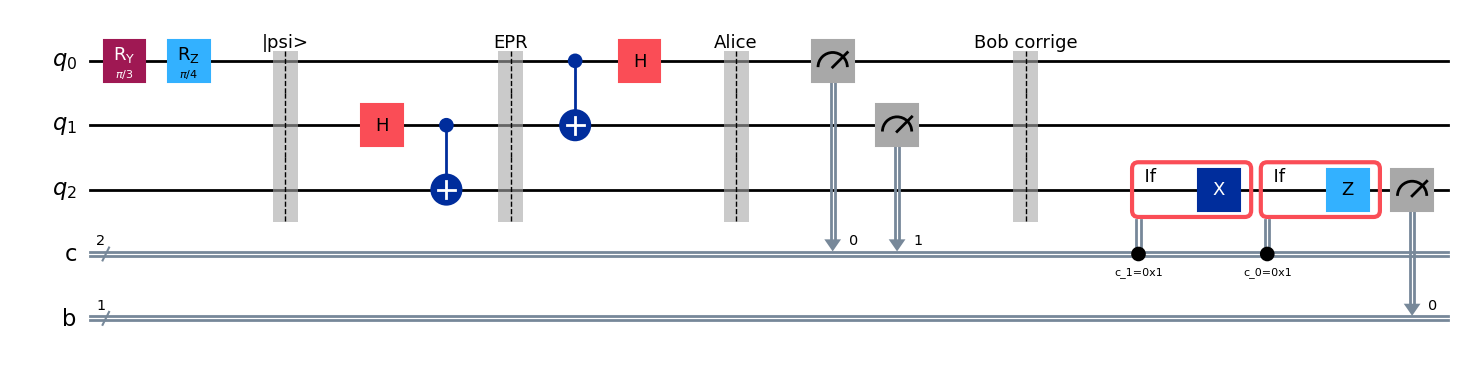

In [ ]:
# Visualizacao do circuito
qc_base.draw('mpl', fold=90)

In [ ]:
# ── Funcao auxiliar: extrai resultado de Bob e calcula fidelidade ──
def extrair_bob_e_fidelidade(counts, p0_teo, p1_teo):
    """
    Recebe o counts do AerSimulator e retorna:
    - p0_bob, p1_bob: probabilidades medidas por Bob
    - fidelidade
    """
    bob_counts = {'0': 0, '1': 0}
    total = sum(counts.values())
    for bitstring, freq in counts.items():
        partes = bitstring.strip().split()
        bob_bit = partes[0]   # primeiro registrador classico = Bob
        bob_counts[bob_bit] = bob_counts.get(bob_bit, 0) + freq

    p0_bob = bob_counts.get('0', 0) / total
    p1_bob = bob_counts.get('1', 0) / total
    fidelidade = (np.sqrt(p0_bob * p0_teo) + np.sqrt(p1_bob * p1_teo)) ** 2
    return p0_bob, p1_bob, fidelidade

## 4. Simulação Ideal (Sem Ruído)

In [ ]:
# ── Teleporte ideal ─────────────────────────────────────────────
SHOTS = 4096
sim_ideal = AerSimulator()

qc_ideal  = circuito_teleporte(theta, phi)
counts_ideal = sim_ideal.run(qc_ideal, shots=SHOTS).result().get_counts()

p0_bob_ideal, p1_bob_ideal, fid_ideal = extrair_bob_e_fidelidade(
    counts_ideal, p0_teorico, p1_teorico
)

print("=== Resultado Ideal ===")
print(f"P(|0>) Alice (teorico): {p0_teorico:.3f}   P(|0>) Bob: {p0_bob_ideal:.3f}")
print(f"P(|1>) Alice (teorico): {p1_teorico:.3f}   P(|1>) Bob: {p1_bob_ideal:.3f}")
print(f"Fidelidade: {fid_ideal:.4f}")

=== Resultado Ideal ===
P(|0>) Alice (teorico): 0.750   P(|0>) Bob: 0.751
P(|1>) Alice (teorico): 0.250   P(|1>) Bob: 0.249
Fidelidade: 1.0000


## 5. Modelo 1: Depolarizacao Customizada

Aplicamos depolarizacao em todas as portas do circuito.
O CNOT recebe um fator de erro maior (3x), pois portas de 2 qubits
acumulam mais ruido em hardware real.

### Limites do parametro de depolarizacao

| Portas | Limite maximo |
|--------|--------------|
| 1 qubit | 1.0 |
| 2 qubits | 16/15 ≈ 1.067 |

In [ ]:
# ── Funcao: teleporte com depolarizacao ─────────────────────────
MAX_2Q = 16 / 15   # limite fisico para 2 qubits

def teleporte_com_depolarizacao(theta, phi, p_dep, shots=4096):
    """Executa o teleporte com erro de depolarizacao em todas as portas."""
    nm = NoiseModel()
    nm.add_all_qubit_quantum_error(depolarizing_error(min(p_dep, 1.0), 1),
                                   ["h", "x", "z", "ry", "rz"])
    nm.add_all_qubit_quantum_error(depolarizing_error(min(p_dep * 3, MAX_2Q), 2),
                                   ["cx"])
    nm.add_all_qubit_readout_error(
        ReadoutError([[1 - p_dep, p_dep], [p_dep, 1 - p_dep]])
    )
    sim = AerSimulator(noise_model=nm)
    qc  = circuito_teleporte(theta, phi)
    counts = sim.run(qc, shots=shots).result().get_counts()
    return counts

# Varre niveis de ruido
niveis = [0.0, 0.01, 0.03, 0.05, 0.10, 0.20, 0.30]
print(f"{'Ruido p':>10} | {'P0 Bob':>8} | {'P1 Bob':>8} | {'Fidelidade':>12}")
print("-" * 48)

fidelidades_dep = []
for p in niveis:
    if p == 0.0:
        sim_z = AerSimulator()
        qc_z  = circuito_teleporte(theta, phi)
        ct    = sim_z.run(qc_z, shots=4096).result().get_counts()
    else:
        ct = teleporte_com_depolarizacao(theta, phi, p)
    p0b, p1b, fid = extrair_bob_e_fidelidade(ct, p0_teorico, p1_teorico)
    fidelidades_dep.append(fid)
    print(f"{p:>10.2f} | {p0b:>8.3f} | {p1b:>8.3f} | {fid:>12.4f}")

   Ruido p |   P0 Bob |   P1 Bob |   Fidelidade
------------------------------------------------
      0.00 |    0.757 |    0.243 |       0.9999
      0.01 |    0.709 |    0.291 |       0.9978
      0.03 |    0.667 |    0.333 |       0.9916
      0.05 |    0.620 |    0.380 |       0.9803
      0.10 |    0.559 |    0.441 |       0.9595
      0.20 |    0.519 |    0.481 |       0.9422
      0.30 |    0.508 |    0.492 |       0.9367


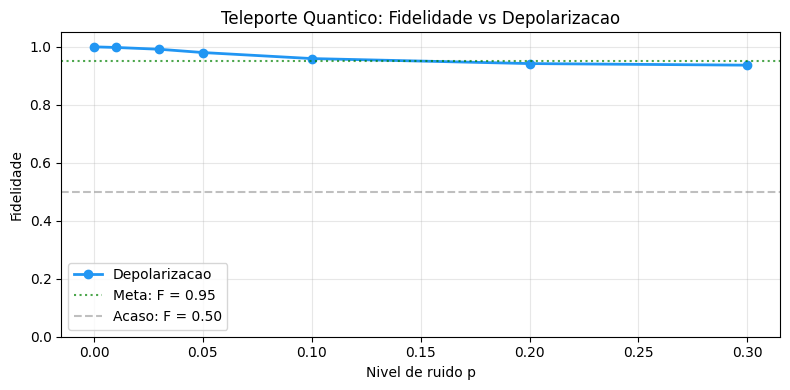

In [ ]:
# Grafico: fidelidade x nivel de ruido (depolarizacao)
plt.figure(figsize=(8, 4))
plt.plot(niveis, fidelidades_dep, 'o-', color='#2196F3', lw=2, label='Depolarizacao')
plt.axhline(0.95, color='green', linestyle=':', alpha=0.7, label='Meta: F = 0.95')
plt.axhline(0.50, color='gray',  linestyle='--', alpha=0.5, label='Acaso: F = 0.50')
plt.xlabel('Nivel de ruido p')
plt.ylabel('Fidelidade')
plt.title('Teleporte Quantico: Fidelidade vs Depolarizacao')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

## 6. Modelo 2: Relaxacao Termica (T1/T2)

Este modelo e o mais realista: captura a decoerencia ao longo do tempo
de execucao do circuito, nao apenas por porta.

| Parametro | Significado | Valor tipico |
|-----------|-------------|-------------|
| T1 | Tempo de relaxacao de amplitude (|1> decai para |0>) | 50–200 us |
| T2 | Tempo de decoerencia de fase (T2 <= 2 T1) | 30–150 us |
| t_gate | Duracao da porta (afeta quanto ruido acumula) | 50–500 ns |

In [ ]:
# ── Modelo T1/T2 ────────────────────────────────────────────────
def teleporte_com_t1t2(theta, phi, T1_ns, T2_ns,
                        t_1q_ns=100, t_cx_ns=300,
                        p_readout=0.03, shots=4096):
    """
    Executa o teleporte com relaxacao termica T1/T2.
    T1_ns, T2_ns: tempos em nanossegundos
    """
    e1q = thermal_relaxation_error(T1_ns, T2_ns, t_1q_ns)
    e2q = thermal_relaxation_error(T1_ns, T2_ns, t_cx_ns).expand(
          thermal_relaxation_error(T1_ns, T2_ns, t_cx_ns)
    )
    nm  = NoiseModel()
    nm.add_all_qubit_quantum_error(e1q, ["h", "x", "z", "ry", "rz"])
    nm.add_all_qubit_quantum_error(e2q, ["cx"])
    nm.add_all_qubit_readout_error(
        ReadoutError([[1 - p_readout, p_readout], [p_readout, 1 - p_readout]])
    )
    sim    = AerSimulator(noise_model=nm)
    qc     = circuito_teleporte(theta, phi)
    counts = sim.run(qc, shots=shots).result().get_counts()
    return counts

# Cenarios: hardware excelente, tipico e degradado
cenarios_t1t2 = [
    ("Hardware excelente",  200_000, 150_000),
    ("Hardware tipico",      50_000,  30_000),
    ("Hardware degradado",   10_000,   6_000),
    ("Hardware muito ruim",   2_000,   1_000),
]

print(f"{'Cenario':<25} | {'T1 (us)':>8} | {'T2 (us)':>8} | {'Fidelidade':>12}")
print("-" * 62)

fidelidades_t1t2 = []
nomes_t1t2       = []
for nome, T1, T2 in cenarios_t1t2:
    ct  = teleporte_com_t1t2(theta, phi, T1, T2)
    p0b, p1b, fid = extrair_bob_e_fidelidade(ct, p0_teorico, p1_teorico)
    fidelidades_t1t2.append(fid)
    nomes_t1t2.append(nome)
    print(f"{nome:<25} | {T1/1000:>8.0f} | {T2/1000:>8.0f} | {fid:>12.4f}")

Cenario                   |  T1 (us) |  T2 (us) |   Fidelidade
--------------------------------------------------------------
Hardware excelente        |      200 |      150 |       0.9989
Hardware tipico           |       50 |       30 |       0.9994
Hardware degradado        |       10 |        6 |       0.9982
Hardware muito ruim       |        2 |        1 |       0.9942


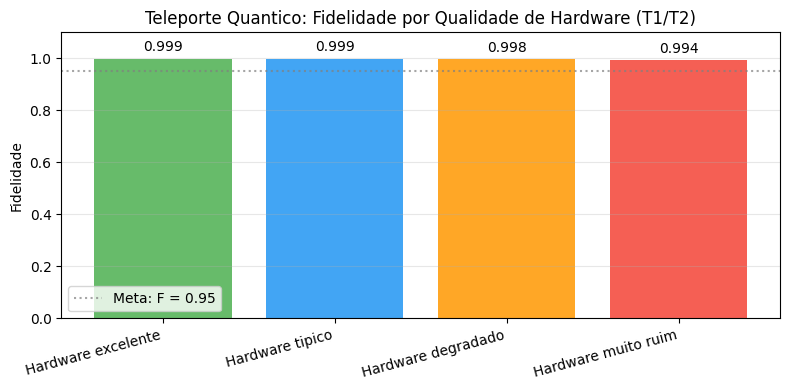

In [ ]:
# Grafico: fidelidade por cenario T1/T2
cores = ['#4CAF50', '#2196F3', '#FF9800', '#f44336']
plt.figure(figsize=(8, 4))
bars = plt.bar(nomes_t1t2, fidelidades_t1t2, color=cores, alpha=0.85)
plt.axhline(0.95, color='gray', linestyle=':', alpha=0.7, label='Meta: F = 0.95')
plt.bar_label(bars, fmt='%.3f', padding=3)
plt.ylabel('Fidelidade')
plt.title('Teleporte Quantico: Fidelidade por Qualidade de Hardware (T1/T2)')
plt.ylim(0, 1.1)
plt.xticks(rotation=15, ha='right')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Modelo 3: FakeNairobi (Hardware IBM Simulado)

O FakeNairobi replica os parametros de ruido calibrados do processador
IBM Nairobi (7 qubits). E o modelo mais proximo do hardware real.

In [ ]:
# ── Teleporte no FakeNairobi ────────────────────────────────────
from qiskit_ibm_runtime.fake_provider import FakeNairobiV2

fake_nairobi = FakeNairobiV2()
sim_nairobi  = AerSimulator.from_backend(fake_nairobi)

print(f"Backend: {fake_nairobi.name}  |  Qubits: {fake_nairobi.num_qubits}")

qc_base   = circuito_teleporte(theta, phi)
qc_transp = transpile(qc_base, backend=sim_nairobi, optimization_level=1)

print(f"\nCircuito original  — portas: {qc_base.count_ops()}  profundidade: {qc_base.depth()}")
print(f"Circuito transpilado — portas: {qc_transp.count_ops()}  profundidade: {qc_transp.depth()}")

counts_nairobi = sim_nairobi.run(qc_transp, shots=SHOTS).result().get_counts()
p0b_n, p1b_n, fid_nairobi = extrair_bob_e_fidelidade(
    counts_nairobi, p0_teorico, p1_teorico
)

print(f"\nP(|0>) Bob: {p0b_n:.3f}  |  P(|1>) Bob: {p1b_n:.3f}")
print(f"Fidelidade FakeNairobi: {fid_nairobi:.4f}")

Backend: fake_nairobi  |  Qubits: 7

Circuito original  — portas: OrderedDict({'barrier': 4, 'measure': 3, 'h': 2, 'cx': 2, 'if_else': 2, 'ry': 1, 'rz': 1})  profundidade: 10
Circuito transpilado — portas: OrderedDict({'rz': 6, 'sx': 4, 'barrier': 4, 'measure': 3, 'cx': 2, 'if_else': 2})  profundidade: 16

P(|0>) Bob: 0.725  |  P(|1>) Bob: 0.275
Fidelidade FakeNairobi: 0.9992


## 8. Comparativo: Todos os Modelos

In [ ]:
# ── Tabela comparativa ──────────────────────────────────────────
modelos = {
    "Ideal":                 fid_ideal,
    "Depol. leve (p=0.01)":  fidelidades_dep[1],
    "Depol. media (p=0.05)": fidelidades_dep[3],
    "Depol. alta (p=0.20)":  fidelidades_dep[5],
    "T1/T2 excelente":       fidelidades_t1t2[0],
    "T1/T2 tipico":          fidelidades_t1t2[1],
    "T1/T2 degradado":       fidelidades_t1t2[2],
    "FakeNairobi":           fid_nairobi,
}

print(f"{'Modelo':<28} | {'Fidelidade':>12} | Qualidade")
print("-" * 60)
for nome, fid in modelos.items():
    if fid >= 0.95:
        status = "Excelente"
    elif fid >= 0.80:
        status = "Bom"
    elif fid >= 0.60:
        status = "Degradado"
    else:
        status = "Inutilizavel"
    print(f"{nome:<28} | {fid:>12.4f} | {status}")

Modelo                       |   Fidelidade | Qualidade
------------------------------------------------------------
Ideal                        |       1.0000 | Excelente
Depol. leve (p=0.01)         |       0.9978 | Excelente
Depol. media (p=0.05)        |       0.9803 | Excelente
Depol. alta (p=0.20)         |       0.9422 | Bom
T1/T2 excelente              |       0.9989 | Excelente
T1/T2 tipico                 |       0.9994 | Excelente
T1/T2 degradado              |       0.9982 | Excelente
FakeNairobi                  |       0.9992 | Excelente


In [ ]:
# Grafico comparativo de barras
fig, ax = plt.subplots(figsize=(11, 5))

nomes_comp = list(modelos.keys())
vals_comp  = list(modelos.values())
cores_comp = ['#4CAF50' if f >= 0.95 else '#FF9800' if f >= 0.70 else '#f44336'
              for f in vals_comp]

bars = ax.bar(nomes_comp, vals_comp, color=cores_comp, alpha=0.85)
ax.axhline(0.95, color='green', linestyle=':', lw=1.5, label='Meta: F >= 0.95')
ax.axhline(0.70, color='orange', linestyle='--', lw=1.5, alpha=0.7, label='Limiar: F = 0.70')
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
ax.set_ylabel('Fidelidade do Teleporte')
ax.set_title('Teleporte Quantico: Comparativo de Fidelidade entre Modelos de Ruido',
             fontweight='bold')
ax.set_ylim(0, 1.12)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

## 9. Mitigacao: Efeito da Transpilacao Otimizada

Otimizar o nivel de transpilacao reduz o numero de portas (especialmente CNOTs),
o que diminui diretamente o ruido acumulado.

In [ ]:
# ── Comparando niveis de otimizacao no FakeNairobi ─────────────
print("Nivel de otimizacao | Profundidade | CNOTs | Fidelidade")
print("-" * 56)

fids_opt = []
for opt in [0, 1, 2, 3]:
    qc_t = transpile(qc_base, backend=sim_nairobi, optimization_level=opt)
    n_cx = qc_t.count_ops().get('cx', 0) + qc_t.count_ops().get('ecr', 0)
    ct   = sim_nairobi.run(qc_t, shots=SHOTS).result().get_counts()
    p0b, p1b, fid = extrair_bob_e_fidelidade(ct, p0_teorico, p1_teorico)
    fids_opt.append(fid)
    print(f"  optimization={opt}       | {qc_t.depth():>12} | {n_cx:>5} | {fid:.4f}")

Nivel de otimizacao | Profundidade | CNOTs | Fidelidade
--------------------------------------------------------
  optimization=0       |           18 |     2 | 0.9982
  optimization=1       |           16 |     2 | 0.9998
  optimization=2       |           16 |     2 | 0.9992
  optimization=3       |           16 |     2 | 0.9993


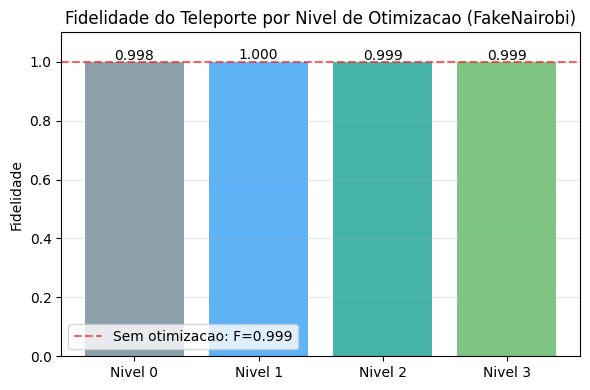

In [ ]:
# Grafico: fidelidade por nivel de otimizacao
plt.figure(figsize=(6, 4))
plt.bar([f'Nivel {i}' for i in range(4)], fids_opt,
        color=['#78909C', '#42A5F5', '#26A69A', '#66BB6A'], alpha=0.85)
plt.axhline(fid_nairobi, color='red', linestyle='--', alpha=0.6,
            label=f'Sem otimizacao: F={fid_nairobi:.3f}')
for i, v in enumerate(fids_opt):
    plt.text(i, v + 0.008, f'{v:.3f}', ha='center', fontsize=10)
plt.ylim(0, 1.1)
plt.ylabel('Fidelidade')
plt.title('Fidelidade do Teleporte por Nivel de Otimizacao (FakeNairobi)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Exercicios

### Exercicio 1 — Impacto do Estado Inicial

Mude os parametros `theta` e `phi` no inicio do notebook e reexecute.
Teste pelo menos 3 estados diferentes:

- **Estado |0>:** theta=0, phi=0
- **Estado |+>:** theta=pi/2, phi=0  
- **Estado aleatorio:** theta=np.pi/5, phi=np.pi/3

Observe: a fidelidade e afetada pelo estado inicial?

In [ ]:
# ── Exercicio 1: Fidelidade para diferentes estados iniciais ────
estados_teste = [
    ("Estado |0>",     0.0,        0.0       ),
    ("Estado |+>",     np.pi/2,    0.0       ),
    ("Estado |1>",     np.pi,      0.0       ),
    ("Estado aleatorio", np.pi/5,  np.pi/3   ),
    ("Estado da aula", np.pi/3,    np.pi/4   ),
]

p_dep_ex1 = 0.05   # ruido fixo para comparar

print(f"{'Estado':<20} | {'P0 teo':>7} | {'P1 teo':>7} | {'Fidelidade':>12}")
print("-" * 56)
for nome, th, ph in estados_teste:
    ct  = teleporte_com_depolarizacao(th, ph, p_dep_ex1, shots=4096)
    p0t = np.cos(th / 2) ** 2
    p1t = np.sin(th / 2) ** 2
    p0b, p1b, fid = extrair_bob_e_fidelidade(ct, p0t, p1t)
    print(f"{nome:<20} | {p0t:>7.3f} | {p1t:>7.3f} | {fid:>12.4f}")

Estado               |  P0 teo |  P1 teo |   Fidelidade
--------------------------------------------------------
Estado |0>           |   1.000 |   0.000 |       0.7485
Estado |+>           |   0.500 |   0.500 |       0.9999
Estado |1>           |   0.000 |   1.000 |       0.7466
Estado aleatorio     |   0.905 |   0.095 |       0.9398
Estado da aula       |   0.750 |   0.250 |       0.9839


### Exercicio 2 — Qual Porta E o Maior Culpado?

O CNOT e a porta mais ruidosa. Neste exercicio, aplique ruido apenas
em portas especificas e compare o impacto na fidelidade:

- Apenas ruido em H e RY/RZ (portas de 1 qubit)
- Apenas ruido no CNOT
- Ruido combinado

In [ ]:
# ── Exercicio 2: Isolando o impacto por tipo de porta ───────────
p_teste = 0.05
SHOTS_EX2 = 4096

def teleporte_ruido_seletivo(theta, phi, p, portas_1q=True, portas_2q=True, shots=4096):
    """Aplica ruido apenas nas portas selecionadas."""
    nm = NoiseModel()
    if portas_1q:
        nm.add_all_qubit_quantum_error(
            depolarizing_error(min(p, 1.0), 1), ["h", "x", "z", "ry", "rz"]
        )
    if portas_2q:
        nm.add_all_qubit_quantum_error(
            depolarizing_error(min(p * 3, MAX_2Q), 2), ["cx"]
        )
    sim    = AerSimulator(noise_model=nm)
    qc     = circuito_teleporte(theta, phi)
    counts = sim.run(qc, shots=shots).result().get_counts()
    return counts

casos = [
    ("Ideal (sem ruido)",       False, False),
    ("Apenas portas 1q",        True,  False),
    ("Apenas CNOT",             False, True ),
    ("Portas 1q + CNOT",        True,  True ),
]

print(f"{'Cenario':<28} | {'Fidelidade':>12}")
print("-" * 44)
for nome, q1, q2 in casos:
    ct = teleporte_ruido_seletivo(theta, phi, p_teste, portas_1q=q1, portas_2q=q2,
                                  shots=SHOTS_EX2)
    _, _, fid = extrair_bob_e_fidelidade(ct, p0_teorico, p1_teorico)
    print(f"{nome:<28} | {fid:>12.4f}")

print(f"\n(p = {p_teste} em todos os casos com ruido)")

Cenario                      |   Fidelidade
--------------------------------------------
Ideal (sem ruido)            |       1.0000
Apenas portas 1q             |       0.9994
Apenas CNOT                  |       0.9948
Portas 1q + CNOT             |       0.9903

(p = 0.05 em todos os casos com ruido)


### Exercicio 3 — Limiar de Ruido

Qual e o nivel maximo de depolarizacao que ainda permite fidelidade acima de 0.90?
Faca uma varredura fina e encontre esse limiar.

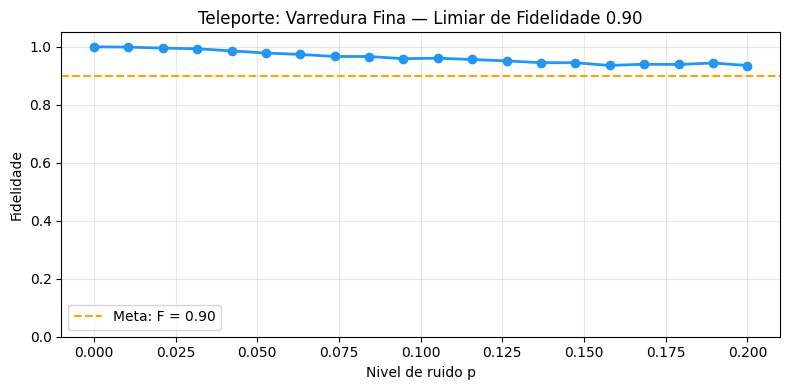

In [ ]:
# ── Exercicio 3: Encontrando o limiar de fidelidade ─────────────
niveis_finos = np.linspace(0.0, 0.20, 20)
fids_finas   = []

for p in niveis_finos:
    if p == 0.0:
        sim_z  = AerSimulator()
        qc_z   = circuito_teleporte(theta, phi)
        ct     = sim_z.run(qc_z, shots=4096).result().get_counts()
    else:
        ct = teleporte_com_depolarizacao(theta, phi, p, shots=4096)
    _, _, fid = extrair_bob_e_fidelidade(ct, p0_teorico, p1_teorico)
    fids_finas.append(fid)

# Encontra limiar
limiar_90 = None
for p, f in zip(niveis_finos, fids_finas):
    if f < 0.90:
        limiar_90 = p
        break

plt.figure(figsize=(8, 4))
plt.plot(niveis_finos, fids_finas, 'o-', color='#2196F3', lw=2)
plt.axhline(0.90, color='orange', linestyle='--', lw=1.5, label='Meta: F = 0.90')
if limiar_90:
    plt.axvline(limiar_90, color='red', linestyle=':', lw=1.5,
                label=f'Limiar: p ≈ {limiar_90:.3f}')
plt.xlabel('Nivel de ruido p')
plt.ylabel('Fidelidade')
plt.title('Teleporte: Varredura Fina — Limiar de Fidelidade 0.90')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

if limiar_90:
    print(f"Fidelidade cai abaixo de 0.90 a partir de p ≈ {limiar_90:.3f}")

## Resumo

### O que observamos

1. **Depolarizacao**: degrada a fidelidade progressivamente — ja em p=0.05 ha perda perceptivel
2. **T1/T2**: hardware tipico (50/30 us) ainda alcanca fidelidade razoavel; hardware degradado falha
3. **FakeNairobi**: representa ruido real de hardware IBM com fidelidade intermediaria
4. **Transpilacao otimizada**: reduz CNOTs e profundidade, melhorando a fidelidade em hardware ruidoso

### Por que o CNOT e tao critico?

O protocolo de teleporte usa 2 CNOTs. Como portas de 2 qubits tem taxas de erro ~10x
maiores que portas de 1 qubit em hardware real, cada CNOT e um ponto critico.
Reduzir o numero de CNOTs via transpilacao e uma das estrategias mais eficazes.

### Comparativo de estrategias

| Estrategia | Custo | Ganho tipico |
|------------|-------|--------------|
| Mais shots | Tempo | Nenhum (nao elimina ruido sistematico) |
| Transpilacao otimizada | Compilacao | Moderado (+5 a +15% de fidelidade) |
| T1/T2 melhor hardware | Financeiro | Alto (depende do hardware) |
| Mitigacao de readout | Circuitos extras | Pequeno a moderado |